In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
# https://www.kaggle.com/datasets/vikrishnan/boston-house-prices

#ZN: 25.000 metrekarenin üzerindeki parseller için imarlı konut arazilerinin oranı. #INDUS: Kasaba başına perakende dışı işletme dönümlerinin oranı
#CHAS: Charles Nehri kukla değişkeni (= arazi nehre komşuysa 1; aksi takdirde 0)
#NOX: nitrik oksit konsantrasyonu (10 milyonda bir parçacık)
#RM: konut başına ortalama oda sayısı
#AGE: 1940'tan önce inşa edilmiş, sahibi tarafından kullanılan konut birimlerinin oranı
#DIS: Boston'daki beş istihdam merkezine ağırlıklı mesafeler
#RAD: radyal otoyollara erişilebilirlik endeksi
#TAX: 10.000 dolar başına tam değerli emlak vergisi oranı
#PTRATIO: kasaba bazında öğrenci-öğretmen oranı 12.
#B: 1000(Bk−0.63)2, burada Bk, kasaba bazında siyahların oranıdır 13.
#LSTAT: Nüfusun % alt statüsü
#MEDV: Sahibi tarafından kullanılan konutların 1000 dolar cinsinden medyan değeri

In [3]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

In [4]:
df = pd.read_csv("boston_house_prices.csv", header=None, delimiter=r"\s+", names=column_names)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
df.shape

(506, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [7]:
import math
def plot_all_histogram(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize = (5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

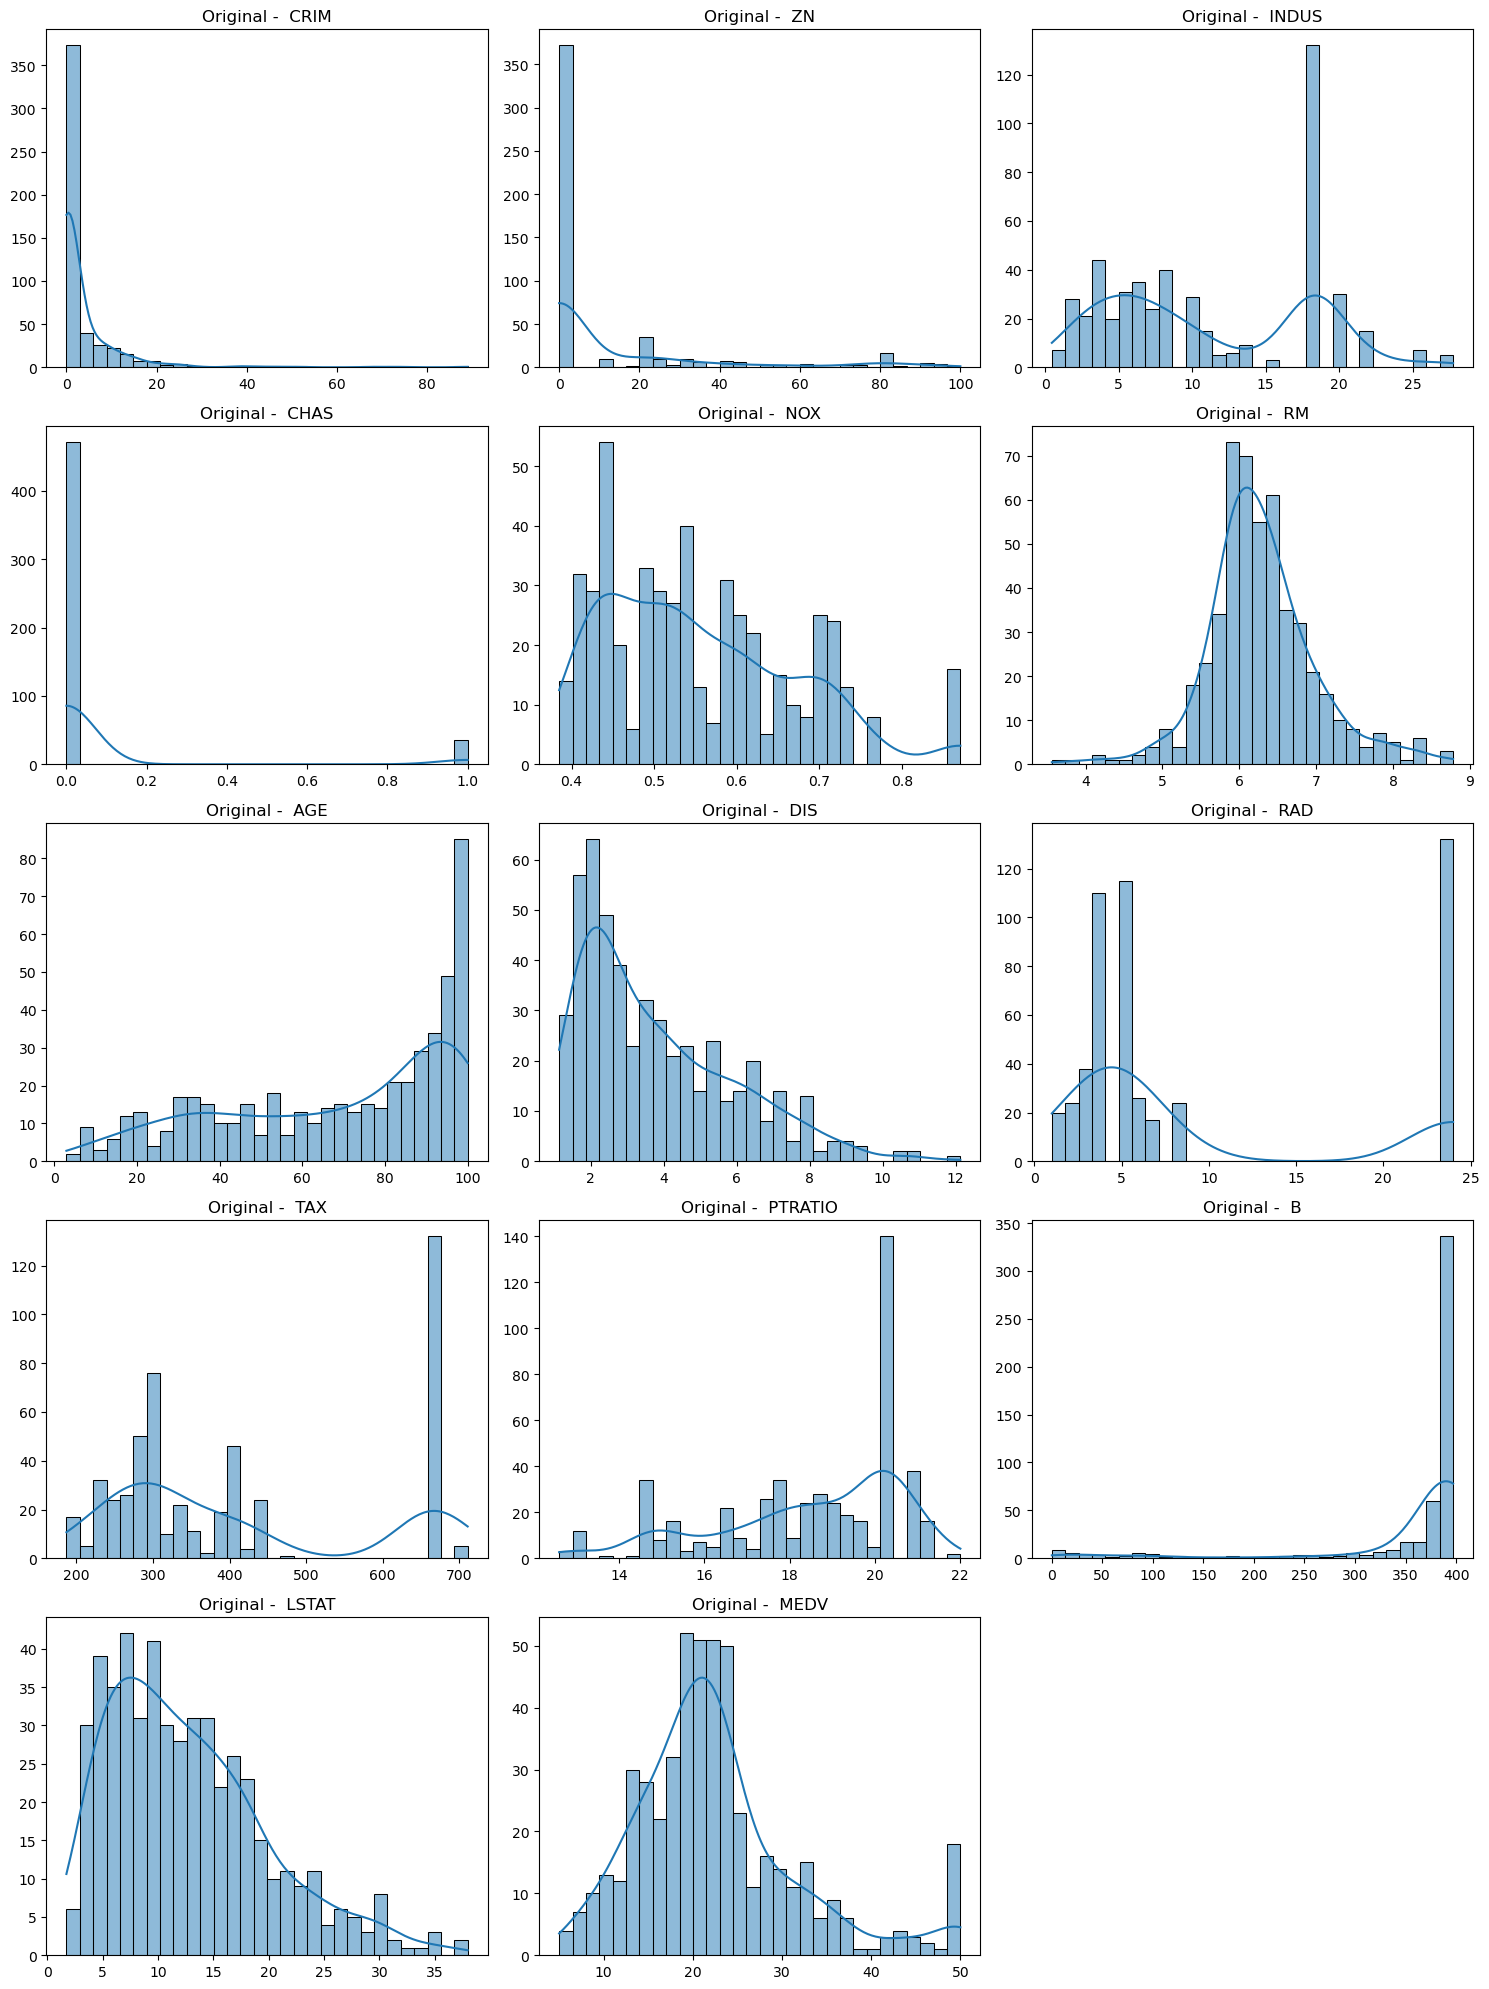

In [8]:
plot_all_histogram(df, title_prefix="Original - ")

In [9]:
from scipy.stats import skew

df.apply(skew).sort_values(ascending=False) # Çarpıklık

CRIM       5.207652
CHAS       3.395799
ZN         2.219063
MEDV       1.104811
DIS        1.008779
RAD        1.001833
LSTAT      0.903771
NOX        0.727144
TAX        0.667968
RM         0.402415
INDUS      0.294146
AGE       -0.597186
PTRATIO   -0.799945
B         -2.881798
dtype: float64

In [10]:
X = df.drop("MEDV", axis = 1)
y = df["MEDV"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [12]:
from sklearn.preprocessing import PowerTransformer

In [13]:
pt_X = PowerTransformer(method="yeo-johnson")

X_train_transformed = pt_X.fit_transform(X_train)
X_test_transformed = pt_X.transform(X_test)

In [14]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=column_names)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=column_names)

In [15]:
X_train_transformed_df.tail(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
394,-0.989679,1.756830,-1.427687,-0.267615,-1.430061,2.176930,-1.250980,0.877290,-0.551621,-1.445304,-1.555351,0.517701,-1.600232
395,-0.999052,1.756830,-1.824600,-0.267615,-1.627511,0.983180,-1.724396,1.580102,-0.944274,0.269485,-0.838866,0.643031,-1.360870
396,1.140514,-0.588616,1.161199,3.736705,2.026049,-0.176989,0.477262,-1.197400,-0.255374,0.275674,-1.555351,-2.695452,0.541625
397,0.934112,-0.588616,1.161199,-0.267615,2.026049,-1.468919,0.938358,-1.207530,-0.255374,0.275674,-1.555351,-2.695093,0.672899
398,1.671812,-0.588616,1.011100,-0.267615,1.247369,-2.862023,0.823304,-1.566796,1.457243,1.370436,0.848622,-1.697823,1.921188
399,1.668295,-0.588616,1.011100,-0.267615,1.072096,1.447764,1.100495,-1.734661,1.457243,1.370436,0.848622,0.643031,0.342306
400,-0.390949,-0.588616,1.382524,-0.267615,0.752694,-0.654775,0.996311,-0.517389,-0.551621,0.472960,1.592342,0.396688,0.542831
401,1.366441,-0.588616,1.011100,-0.267615,1.206460,0.184264,1.021234,-1.275079,1.457243,1.370436,0.848622,0.643031,1.013945
402,-0.636275,1.664783,-0.676234,-0.267615,-1.216540,-0.973231,-0.000938,1.644135,0.171014,-0.249768,0.159469,0.409545,0.922866
403,1.272838,-0.588616,1.011100,-0.267615,1.321096,-0.430855,0.689192,-0.431168,1.457243,1.370436,0.848622,-2.709398,0.978341


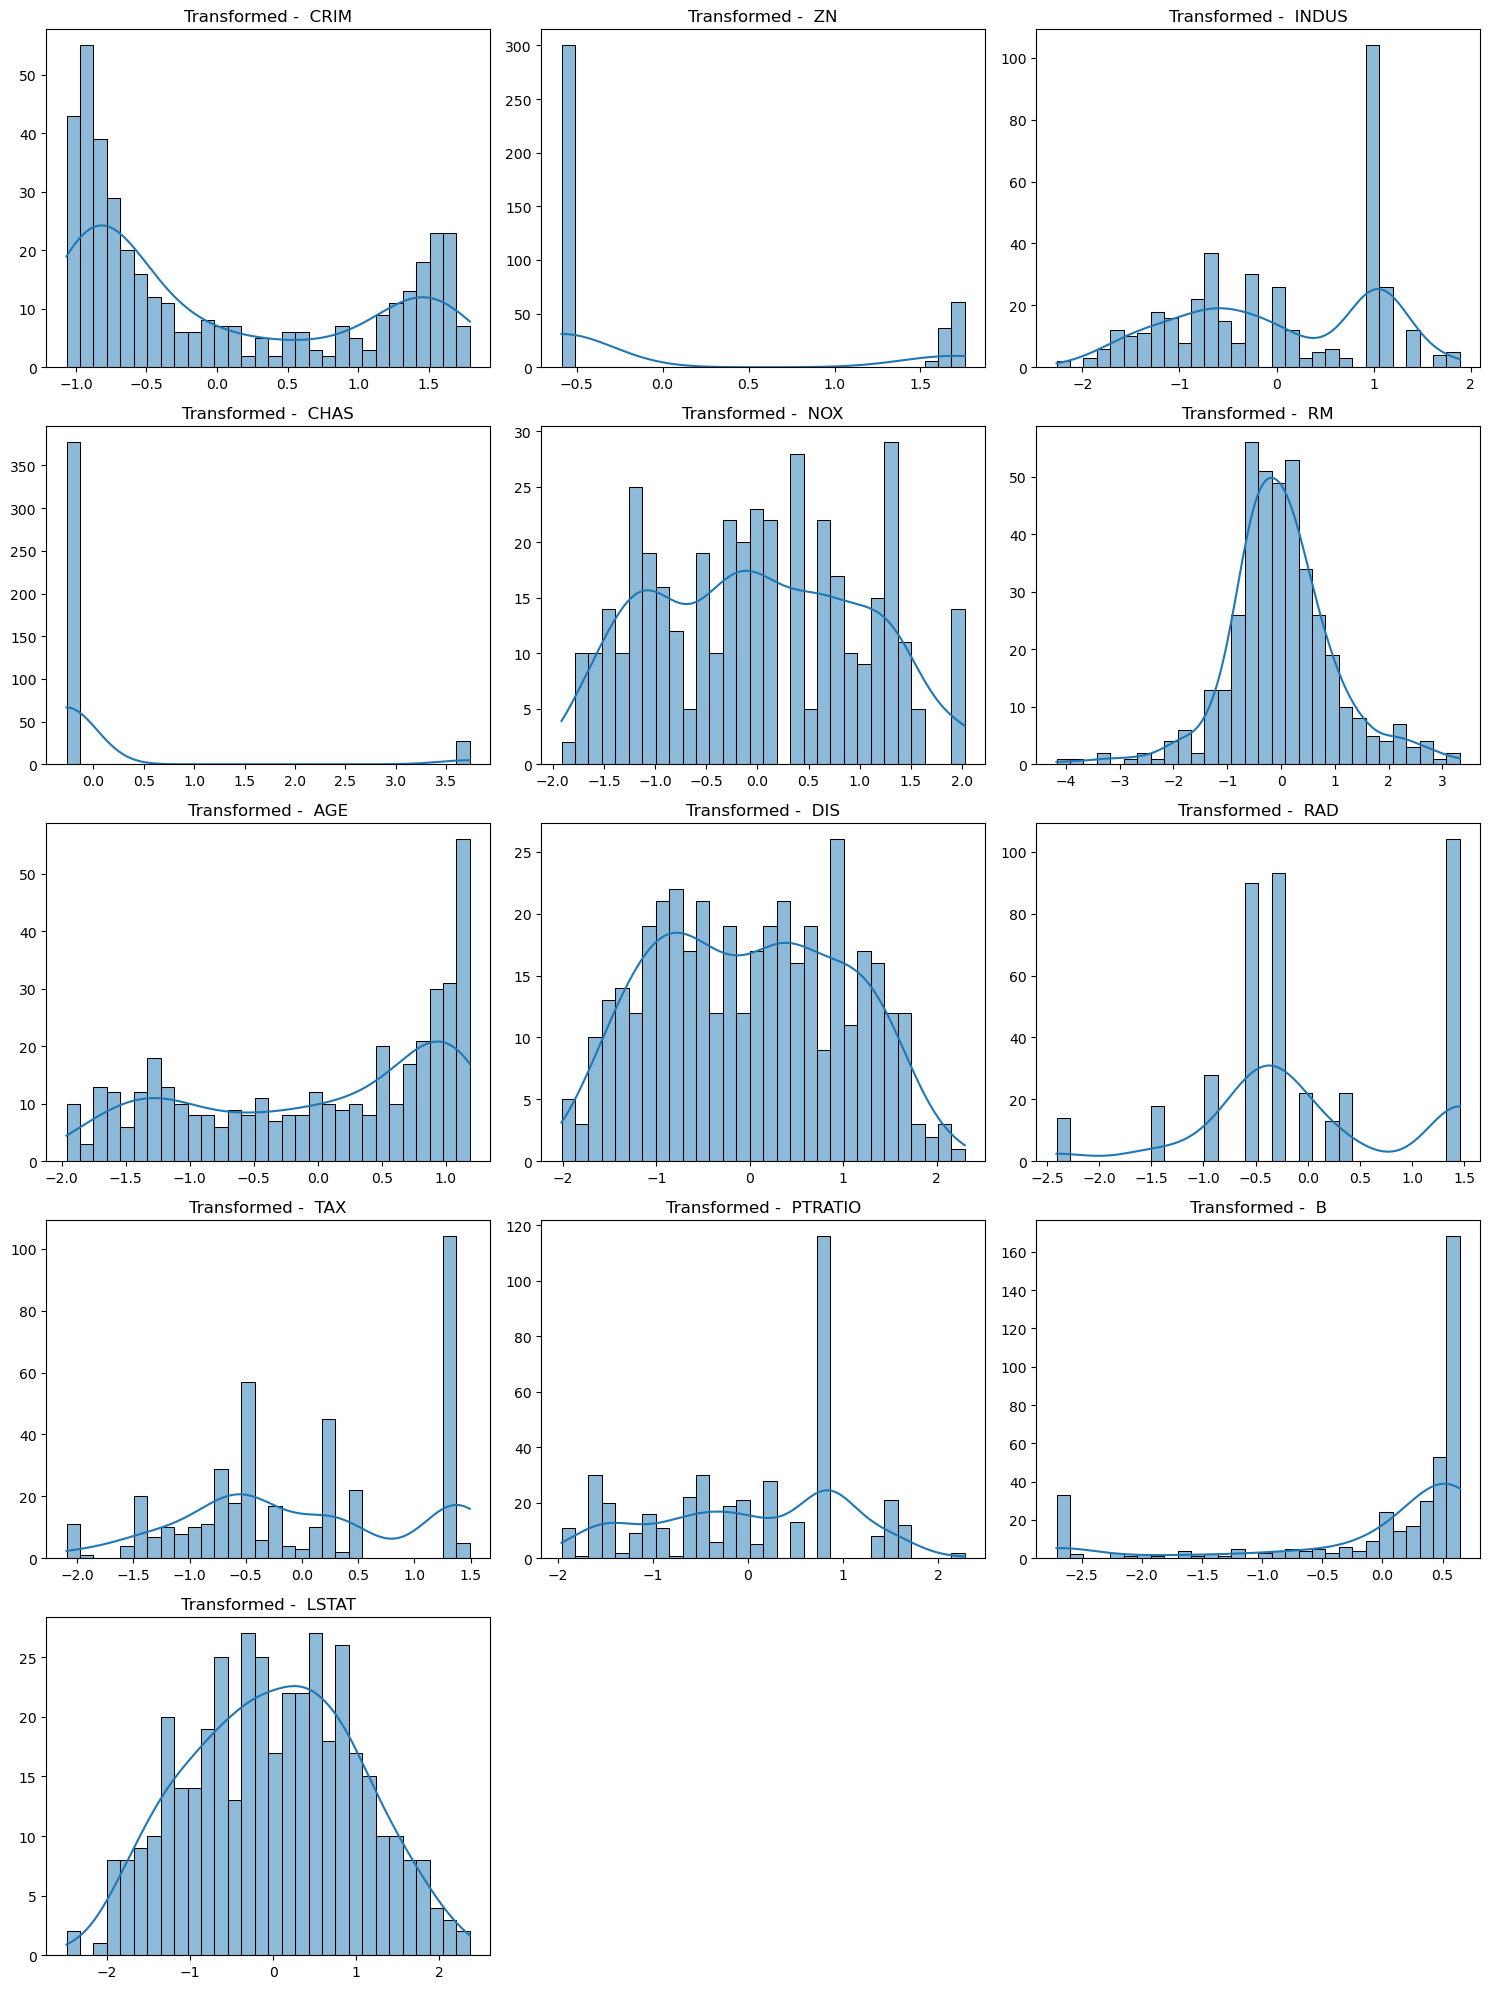

In [16]:
plot_all_histogram(X_train_transformed_df, title_prefix="Transformed - ")

In [17]:
from scipy.stats import boxcox

y_train_transformed, lambda_y = boxcox(y_train)

In [18]:
y_train_transformed

array([4.84566478, 2.6337955 , 4.7877742 , 3.60496591, 4.34497185,
       4.19030731, 4.21544245, 5.31802204, 4.77471725, 4.18186609,
       4.10442777, 5.8511485 , 4.24852567, 4.1218698 , 4.46754554,
       4.07800566, 3.15055966, 4.74838699, 4.41472178, 2.82185272,
       3.9028955 , 5.8511485 , 4.39940407, 3.15055966, 4.23204469,
       5.8511485 , 5.70646282, 4.38398352, 5.11031782, 4.09565525,
       3.85438551, 3.62690465, 3.37189121, 4.44505472, 5.19438693,
       4.36845856, 4.35282759, 4.3291788 , 4.30528212, 3.9783335 ,
       4.13917647, 4.56971198, 4.16488776, 4.06912797, 4.42993817,
       2.96306251, 4.69483551, 3.03730045, 4.01510096, 3.85438551,
       3.48002143, 4.58394834, 5.8511485 , 3.94093982, 4.37623419,
       4.91457817, 4.27302406, 4.64696352, 4.42234255, 4.15635011,
       5.22723362, 2.96306251, 4.68125649, 4.83292044, 5.00549881,
       4.39170675, 3.9783335 , 4.08684798, 3.33454579, 4.20709524,
       4.29726046, 3.6913874 , 4.88974588, 3.85438551, 3.45647

In [19]:
lambda_y

np.float64(0.19365111420999034)

In [20]:
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model = LinearRegression()
model.fit(X_train_transformed, y_train_transformed)

LinearRegression()

In [23]:
y_pred_transformed = model.predict(X_test_transformed)

In [24]:
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y) # y_test ile y_pred_origial kıyaslanır

In [25]:
from sklearn.metrics import r2_score

print("Score: ", r2_score(y_test, y_pred_original))

# yanlış kullanım
print("❌ Score: ", r2_score(y_test, y_pred_transformed))

Score:  0.7755639716957539
❌ Score:  -3.846659075199055


In [26]:
# Tranformation Yapmadan Eğitim
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred = model.predict(X_test)

print("Score: ", r2_score(y_test, y_pred))

Score:  0.6920749038652123
